# Laboratorio 2A — Visión por Computador

Notebook interactivo para practicar:

1. Carga y visualización de imágenes.
2. Redimensionamiento manteniendo proporciones.
3. Threshold en escala de grises con NumPy.
4. Threshold usando los canales RGB.
5. Nube de puntos RGB.
6. Eliminación heurística del fondo.
7. Convolución con distintos kernels.

> Coloca una imagen de un gato sobre césped en la misma carpeta del notebook y cambia `IMAGE_PATH` si es necesario.


In [1]:
import sys

print("Python que está usando este notebook:")
print(sys.executable)

Python que está usando este notebook:
c:\Users\Mishelle\Desktop\Vision\.venv\Scripts\python.exe


-  Si te falta alguna librería, descomenta y ejecuta:
- %pip install numpy matplotlib pillow opencv-python ipywidgets


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [3]:
import ipywidgets as widgets
from ipywidgets import interact, IntSlider, IntRangeSlider, Dropdown

plt.rcParams["figure.figsize"] = (7, 5)

## 1. Cargar y visualizar la imagen

Shape: (282, 381, 3)
Tipo de dato: uint8
Rango de valores: 0 a 255


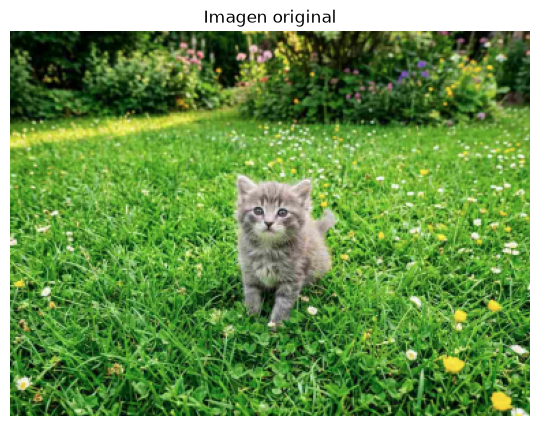

In [4]:
IMAGE_PATH = "gato_en_cesped.png"   # <-- cambia este nombre por el de tu archivo

img_pil = Image.open(IMAGE_PATH).convert("RGB")
img_rgb = np.array(img_pil)

print("Shape:", img_rgb.shape)
print("Tipo de dato:", img_rgb.dtype)
print("Rango de valores:", img_rgb.min(), "a", img_rgb.max())

plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")
plt.show()


## 2. Redimensionamiento manteniendo proporciones

Si la imagen original tiene ancho $W$ y alto $H$, al elegir un nuevo ancho $W_n$ usamos:

$$H_n = H \frac{W_n}{W}$$


In [5]:
def redimensionar_manteniendo_ratio(img, nuevo_ancho):
    h, w = img.shape[:2]
    ratio = h / w

    nuevo_alto = int(nuevo_ancho * ratio)

    return cv2.resize(
        img,
        (nuevo_ancho, nuevo_alto),
        interpolation=cv2.INTER_AREA
    )


@interact(
    nuevo_ancho=IntSlider(
        min=100,
        max=800,
        step=50,
        value=400,
        continuous_update=False   # <- importante
    )
)
def explorar_tamano(nuevo_ancho=400):

    reducida = redimensionar_manteniendo_ratio(
        img_rgb,
        nuevo_ancho
    )

    print("Original:", img_rgb.shape)
    print("Redimensionada:", reducida.shape)

    plt.figure(figsize=(6, 5))
    plt.imshow(reducida)
    plt.title(f"Ancho = {nuevo_ancho}px")
    plt.axis("off")
    plt.show()

interactive(children=(IntSlider(value=400, continuous_update=False, description='nuevo_ancho', max=800, min=10…

## 3. Escala de grises + Threshold con NumPy

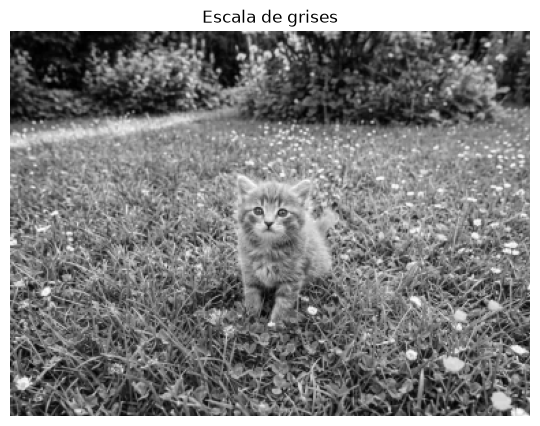

In [6]:
# Conversión RGB -> gris usando luminancia aproximada.
R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

gris = 0.299 * R + 0.587 * G + 0.114 * B
gris = gris.astype(np.uint8)

plt.imshow(gris, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")
plt.show()


In [7]:
@interact(
    T=IntSlider(
        min=0,
        max=255,
        step=1,
        value=128,
        continuous_update=False
    )
)
def threshold_gris(T=128):

    binaria = np.where(
        gris >= T,
        255,
        0
    ).astype(np.uint8)

    fig, ax = plt.subplots(
        1, 2,
        figsize=(10, 4)
    )

    ax[0].imshow(gris, cmap="gray")
    ax[0].set_title("Grises")
    ax[0].axis("off")

    ax[1].imshow(
        binaria,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax[1].set_title(f"Threshold T={T}")
    ax[1].axis("off")

    plt.show()
    plt.close(fig)

interactive(children=(IntSlider(value=128, continuous_update=False, description='T', max=255), Output()), _dom…

## 4. Threshold usando los 3 canales RGB

En vez de decidir usando solo intensidad, seleccionamos un rango válido para cada canal.
Esto permite experimentar con qué región del espacio RGB podría corresponder al gato.


In [ ]:
def mascara_rgb(rango_r=(0,255), rango_g=(0,255), rango_b=(0,255)):
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]

    mask = (
        (R >= rango_r[0]) & (R <= rango_r[1]) &
        (G >= rango_g[0]) & (G <= rango_g[1]) &
        (B >= rango_b[0]) & (B <= rango_b[1])
    )

    resultado = np.zeros_like(img_rgb)
    resultado[mask] = img_rgb[mask]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].imshow(img_rgb)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Máscara RGB")
    ax[1].axis("off")

    ax[2].imshow(resultado)
    ax[2].set_title("Pixeles seleccionados")
    ax[2].axis("off")

    plt.show()

interact(
    mascara_rgb,
    rango_r=IntRangeSlider(value=(0,255), min=0, max=255, step=1, description="R"),
    rango_g=IntRangeSlider(value=(0,255), min=0, max=255, step=1, description="G"),
    rango_b=IntRangeSlider(value=(0,255), min=0, max=255, step=1, description="B")
);


interactive(children=(IntRangeSlider(value=(0, 255), description='R', max=255), IntRangeSlider(value=(0, 255),…

## 5. Nube de puntos en el espacio RGB

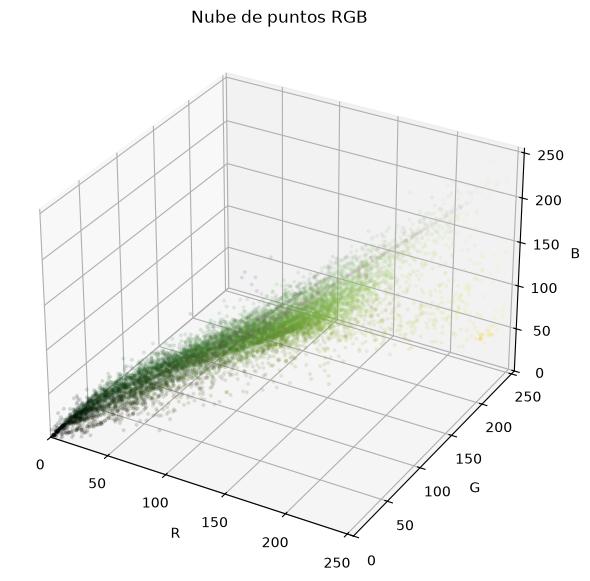

In [9]:
# Para no volver lenta la gráfica, tomamos una muestra aleatoria de pixeles.
pixels = img_rgb.reshape(-1, 3)

N = min(10000, len(pixels))
rng = np.random.default_rng(42)
idx = rng.choice(len(pixels), size=N, replace=False)
muestra = pixels[idx]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    muestra[:, 0],
    muestra[:, 1],
    muestra[:, 2],
    c=muestra / 255.0,
    s=4,
    alpha=0.35
)

ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.set_zlim(0, 255)
ax.set_title("Nube de puntos RGB")

plt.show()


## 6. Intento de remover el césped

Para una imagen de gato sobre césped, una heurística sencilla es detectar píxeles donde el canal verde domina sobre rojo y azul.

No es un segmentador universal: sirve para experimentar con la idea de separar regiones según color.


In [10]:
def remover_verde(g_min=70, margen=20):
    R = img_rgb[:, :, 0].astype(np.int16)
    G = img_rgb[:, :, 1].astype(np.int16)
    B = img_rgb[:, :, 2].astype(np.int16)

    # Heurística: consideramos "césped" a un píxel si G es suficientemente alto
    # y supera a R y B por cierto margen.
    fondo_verde = (
        (G >= g_min) &
        (G - R >= margen) &
        (G - B >= margen)
    )

    mascara_gato_aprox = ~fondo_verde

    resultado = np.zeros_like(img_rgb)
    resultado[mascara_gato_aprox] = img_rgb[mascara_gato_aprox]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    ax[0].imshow(img_rgb)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(mascara_gato_aprox, cmap="gray")
    ax[1].set_title("Máscara aproximada")
    ax[1].axis("off")

    ax[2].imshow(resultado)
    ax[2].set_title("Fondo verde removido")
    ax[2].axis("off")

    plt.show()

interact(
    remover_verde,
    g_min=IntSlider(min=0, max=255, step=5, value=70, description="G mín"),
    margen=IntSlider(min=0, max=100, step=2, value=20, description="Margen")
);


interactive(children=(IntSlider(value=70, description='G mín', max=255, step=5), IntSlider(value=20, descripti…

## 7. Convolución con OpenCV

Probamos varios kernels para observar cómo cambia la imagen.


In [ ]:
def aplicar_convolucion(tipo="Box blur", ksize=3):
    # ksize debe ser impar
    if ksize % 2 == 0:
        ksize += 1

    if tipo == "Box blur":
        kernel = np.ones((ksize, ksize), dtype=np.float32) / (ksize * ksize)

    elif tipo == "Sharpen":
        kernel = np.array([
            [ 0, -1,  0],
            [-1,  5, -1],
            [ 0, -1,  0]
        ], dtype=np.float32)

    elif tipo == "Bordes":
        kernel = np.array([
            [-1, -1, -1],
            [-1,  8, -1],
            [-1, -1, -1]
        ], dtype=np.float32)

    elif tipo == "Emboss":
        kernel = np.array([
            [-2, -1, 0],
            [-1,  1, 1],
            [ 0,  1, 2]
        ], dtype=np.float32)

    resultado = cv2.filter2D(img_rgb, ddepth=-1, kernel=kernel)

    print("Kernel:")
    print(kernel)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(img_rgb)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(resultado)
    ax[1].set_title(tipo)
    ax[1].axis("off")

    plt.show()

interact(
    aplicar_convolucion,
    tipo=Dropdown(
        options=["Box blur", "Sharpen", "Bordes", "Emboss"],
        value="Box blur",
        description="Kernel"
    ),
    ksize=IntSlider(min=3, max=15, step=2, value=3, description="Tamaño")
);


## 8. Comparar varios Box Kernels a la vez

Así puedes ver cómo aumenta el suavizado al crecer el kernel.


In [ ]:
tamanos = [3, 5, 9, 15]

fig, axes = plt.subplots(1, len(tamanos) + 1, figsize=(18, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

for i, k in enumerate(tamanos, start=1):
    kernel = np.ones((k, k), dtype=np.float32) / (k * k)
    resultado = cv2.filter2D(img_rgb, -1, kernel)

    axes[i].imshow(resultado)
    axes[i].set_title(f"Box {k}x{k}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## Preguntas para experimentar

1. ¿Qué ocurre al aumentar el threshold en escala de grises?
2. ¿Puedes encontrar rangos RGB que seleccionen principalmente al gato?
3. ¿En qué zona de la nube RGB se concentra el césped?
4. ¿Qué falla en la heurística de eliminación de fondo?
5. ¿Qué efecto tiene aumentar el tamaño de un Box Kernel?
6. ¿Qué kernels resaltan bordes y cuáles suavizan?
